Functional API continue ... full walkthrough

![lec_img/fun_api.png](lec_img/fun_api.png)

In [5]:
!pip install kagglehub

In [12]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jangedoo/utkface-new")

print("Path to dataset files:", path)

/Users/praveenk/Documents/Deep_learning/tf-metal/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/praveenk/.cache/kagglehub/datasets/jangedoo/utkface-new/versions/1


In [4]:
pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 18.1 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pandas]2m2/3 [pandas]

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: /Users/praveenk/Documents/Deep_learning/tf-metal/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [43]:
pip install keras


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: /Users/praveenk/Documents/Deep_learning/tf-metal/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [58]:
# here in the dataset it contains images of people -> and the (file name) contains the age and the gender with it
import os
os.environ["PATH"] += os.pathsep + "/opt/homebrew/bin"

import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [68]:
path = '/Users/praveenk/.cache/kagglehub/datasets/jangedoo/utkface-new/versions/1/utkface_aligned_cropped/UTKFace'

age = []
gender = []
img_path = []

for file in os.listdir(path):
    age.append(int(file.split('_')[0]))
    gender.append(int(file.split('_')[1]))
    img_path.append(file)


In [69]:
len(img_path)

23708

In [70]:
df = pd.DataFrame({'age':age, 'gender':gender, 'img':img_path})
df

,age,gender,img
0,9,1,9_1_2_20161219204347420.jpg.chip.jpg
1,36,0,36_0_1_20170117163203851.jpg.chip.jpg
2,86,1,86_1_0_20170120225751953.jpg.chip.jpg
3,26,1,26_1_0_20170116171048641.jpg.chip.jpg
4,1,1,1_1_2_20161219154612988.jpg.chip.jpg
...,...,...,...
23703,35,0,35_0_0_20170117155112202.jpg.chip.jpg
23704,52,0,52_0_3_20170119200211340.jpg.chip.jpg
23705,26,0,26_0_1_20170116010114628.jpg.chip.jpg
23706,28,0,28_0_1_20170117015458481.jpg.chip.jpg


In [71]:
train_df = df.sample(frac=1, random_state=0).iloc[:20000]
test_df = df.sample(frac=1, random_state=0).iloc[20000:]

In [72]:
train_df.shape

(20000, 3)

In [73]:
test_df.shape

(3708, 3)

In [74]:
train_datagen = ImageDataGenerator(rescale=1./255, 
                                    rotation_range=30, 
                                    width_shift_range=0.2, 
                                    height_shift_range=0.2, 
                                    shear_range=0.2, 
                                    zoom_range=0.2,
                                    horizontal_flip=True)
test_datagen = ImageDataGenerator(rescale=1./255)

In [85]:
train_generator = train_datagen.flow_from_dataframe(train_df,
                                                directory=path, 
                                                x_col= 'img',
                                                y_col=['age','gender'],
                                                target_size=(200,200), 
                                                class_mode= 'raw')
test_generator = test_datagen.flow_from_dataframe(test_df,
                                                directory=path, 
                                                x_col= 'img',
                                                y_col=['age','gender'],
                                                target_size=(200,200), 
                                                class_mode= 'raw')

Found 20000 validated image filenames.
Found 3708 validated image filenames.


In [86]:
from keras.applications.vgg16 import VGG16
from keras.layers import *
from keras.models import Model

In [87]:
# b/c i needed only the trainable base so i remove the ending part

vggnet = VGG16(include_top=False, input_shape=(200,200,3))

In [88]:
vggnet.trainable = False

# lets take the last layer of the base
output = vggnet.layers[-1].output

flatten = Flatten()(output)

dense1 = Dense(512, activation='relu')(flatten)
dense2 = Dense(512, activation='relu')(flatten)

dense3 = Dense(512, activation='relu')(dense1)
dense4 = Dense(512, activation='relu')(dense2)

output1 = Dense(1, activation='linear', name='age')(dense3)
output2 = Dense(1, activation='sigmoid', name='gender')(dense4)

In [89]:
model = Model(inputs=vggnet.input, outputs=[output1, output2])

In [90]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 200, 200,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 200, 200,  │      1,792 │ input_layer_2[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 200, 200,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 100, 100,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 100, 100,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 100, 100,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 50, 50,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 50, 50,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 50, 50,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 50, 50,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 25, 25,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 25, 25,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 25, 25,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 25, 25,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 12, 12,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 12, 12,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 12, 12,    │  2,359,808 │ block5_conv1[0][

 Total params: 34,116,418 (130.14 MB)

 Trainable params: 19,401,730 (74.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

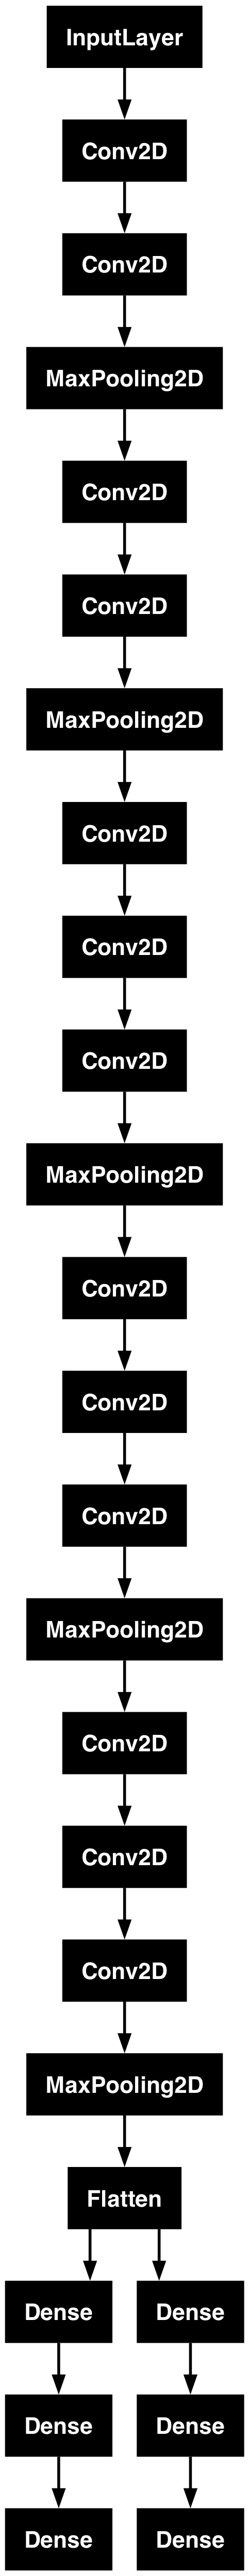

In [91]:
from keras.utils import plot_model
plot_model(model)

In [92]:
model.compile(optimizer='adam', 
              loss={'age':'mae', 'gender':'binary_crossentropy'}, 
              metrics={'age':'mae', 'gender':'accuracy'}, 
              loss_weights={'age':1, 'gender':99})


In [96]:
# having some issue with the model.fit for multiple output case
# history = model.fit(
#     train_generator,
#     validation_data=test_generator,
#     epochs=10
# )